# Phase 7 — Customer Lifetime Value Prediction (Regression)
Intelligent E-Commerce Customer Analytics Platform (Olist dataset)

**Objective:** predict future revenue expected from each customer.

Uses the same leakage-safe temporal-cutoff design as Phase 6: features are
computed only from orders *before* the cutoff; the regression target is
**total spending in the 90 days after the cutoff** (0 for customers who
don't return — this is the realistic, decision-useful quantity a marketing
team would want to forecast, not a hypothetical "value if they never churned").

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
OUT = "../outputs/"

orders = pd.read_csv(OUT + "orders_master_clean.csv", parse_dates=["order_purchase_timestamp"])
delivered = orders[orders["order_status"] == "delivered"].copy()

CUTOFF = pd.Timestamp("2018-04-01")
LABEL_WINDOW_END = CUTOFF + pd.Timedelta(days=90)

pre_cutoff = delivered[delivered["order_purchase_timestamp"] <= CUTOFF]
post_cutoff = delivered[(delivered["order_purchase_timestamp"] > CUTOFF) &
                         (delivered["order_purchase_timestamp"] <= LABEL_WINDOW_END)]

## 1. Point-in-time features (identical construction to Phase 6, for consistency)

In [2]:
snapshot = CUTOFF + pd.Timedelta(days=1)

feat = pre_cutoff.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spending=("total_payment_value", "sum"),
    avg_order_value=("total_payment_value", "mean"),
    total_items=("n_items", "sum"),
    avg_basket_size=("n_items", "mean"),
    avg_review_rating=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    late_delivery_rate=("is_late", "mean"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max"),
    n_distinct_products=("n_distinct_products", "sum"),
    customer_state=("customer_state", "first"),
).reset_index()

feat["recency_days"] = (snapshot - feat["last_purchase"]).dt.days
feat["tenure_days"] = (snapshot - feat["first_purchase"]).dt.days
feat["frequency"] = feat["total_orders"]
feat["order_frequency_rate"] = feat["frequency"] / feat["tenure_days"].clip(lower=1) * 30
for col in ["avg_review_rating", "avg_delivery_days", "late_delivery_rate"]:
    feat[col] = feat[col].fillna(feat[col].median())

## 2. Regression target: spend in the 90 days after cutoff

Target distribution:
count    62299.000000
mean         1.065186
std         18.104829
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1402.320000
Name: future_spend_90d, dtype: float64

% customers with future_spend_90d > 0: 0.68%


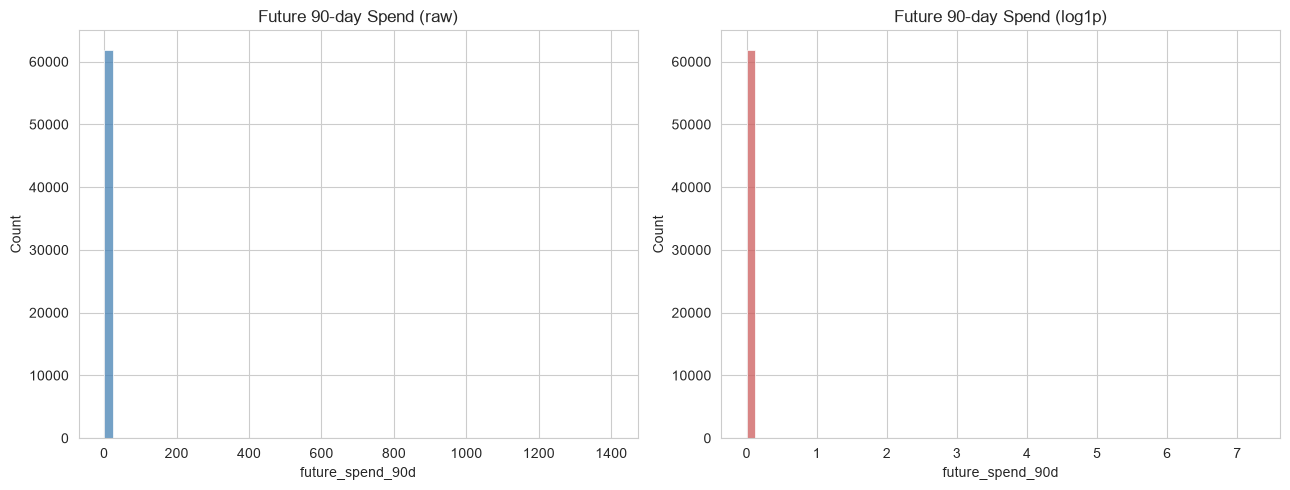

In [3]:
future_spend = post_cutoff.groupby("customer_unique_id")["total_payment_value"].sum().rename("future_spend_90d")
feat = feat.merge(future_spend, on="customer_unique_id", how="left")
feat["future_spend_90d"] = feat["future_spend_90d"].fillna(0.0)

print("Target distribution:")
print(feat["future_spend_90d"].describe())
print(f"\n% customers with future_spend_90d > 0: {(feat['future_spend_90d'] > 0).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(feat["future_spend_90d"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Future 90-day Spend (raw)")
sns.histplot(np.log1p(feat["future_spend_90d"]), bins=60, ax=axes[1], color="indianred")
axes[1].set_title("Future 90-day Spend (log1p)")
plt.tight_layout()
plt.savefig(OUT + "clv_target_distribution.png", dpi=110)
plt.show()

## 3. Train/test split + log-transform target
The target is extremely zero-inflated and right-skewed (matches the ~0.7% repurchase rate seen
in Phase 6). We model `log1p(future_spend_90d)` and report metrics back on the original scale.

In [4]:
feature_cols = ["total_orders", "total_spending", "avg_order_value", "total_items", "avg_basket_size",
                 "avg_review_rating", "avg_delivery_days", "late_delivery_rate", "recency_days",
                 "tenure_days", "order_frequency_rate", "n_distinct_products"]
cat_cols = ["customer_state"]

X = feat[feature_cols + cat_cols]
y_log = np.log1p(feat["future_spend_90d"])

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, feat["future_spend_90d"], test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), feature_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 4. Train & compare 5 regression models

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   random_state=RANDOM_STATE, verbose=-1),
}

def mape(y_true, y_pred, eps=1.0):
    # standard MAPE is undefined at y_true=0 (which is ~99% of rows here) -> use eps floor
    return np.mean(np.abs(y_true - y_pred) / np.maximum(y_true, eps)) * 100

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train_log)
    preds_log = model.predict(X_test_proc)
    preds = np.expm1(preds_log).clip(min=0)  # back to original R$ scale
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test_raw, preds)),
        "MAE": mean_absolute_error(y_test_raw, preds),
        "MAPE (eps=1)": mape(y_test_raw.values, preds),
        "R2": r2_score(y_test_raw, preds),
    })
    fitted_models[name] = model
    print(f"{name:20s} done.")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("\nModel comparison:")
print(results_df.round(3))

Linear Regression    done.


Random Forest        done.


Gradient Boosting    done.


XGBoost              done.


LightGBM             done.

Model comparison:
               Model    RMSE    MAE  MAPE (eps=1)     R2
0  Gradient Boosting  13.020  0.872         4.460  0.002
1            XGBoost  13.039  0.877         4.396 -0.001
2      Random Forest  13.050  0.875         4.032 -0.003
3           LightGBM  13.056  0.877         4.133 -0.004
4  Linear Regression  13.056  0.875         3.947 -0.004


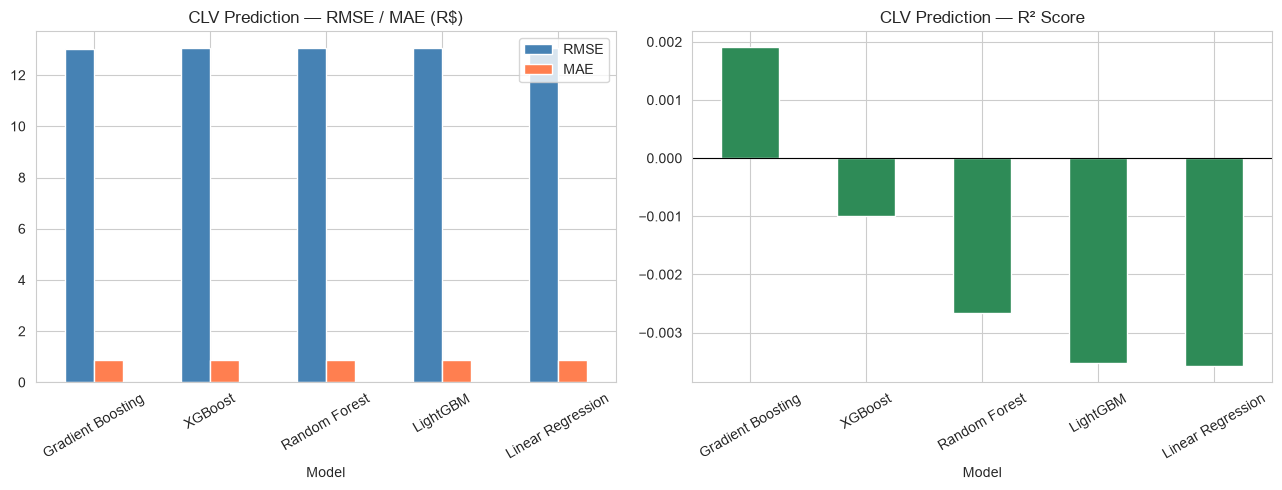

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
results_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("CLV Prediction — RMSE / MAE (R$)")
plt.setp(axes[0].get_xticklabels(), rotation=30)

results_df.set_index("Model")["R2"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("CLV Prediction — R² Score")
axes[1].axhline(0, color="black", linewidth=0.8)
plt.setp(axes[1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig(OUT + "clv_model_comparison.png", dpi=110)
plt.show()

## 5. Best model — predicted vs actual

C:\Users\mahes\AppData\Local\Temp\ipykernel_13216\3235971240.py:9: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, cap)
C:\Users\mahes\AppData\Local\Temp\ipykernel_13216\3235971240.py:10: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, cap)


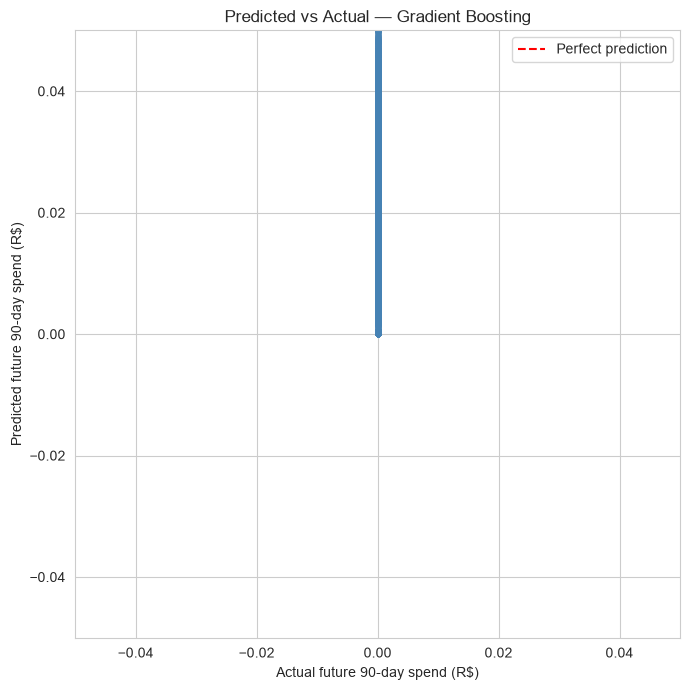

In [7]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
preds_best = np.expm1(best_model.predict(X_test_proc)).clip(min=0)

fig, ax = plt.subplots(figsize=(7, 7))
cap = np.percentile(y_test_raw, 99)  # trim view for readability; metrics above use full data
ax.scatter(y_test_raw, preds_best, alpha=0.3, s=10, color="steelblue")
ax.plot([0, cap], [0, cap], "r--", label="Perfect prediction")
ax.set_xlim(0, cap)
ax.set_ylim(0, cap)
ax.set_xlabel("Actual future 90-day spend (R$)")
ax.set_ylabel("Predicted future 90-day spend (R$)")
ax.set_title(f"Predicted vs Actual — {best_name}")
ax.legend()
plt.tight_layout()
plt.savefig(OUT + "clv_pred_vs_actual.png", dpi=110)
plt.show()

## 6. Feature importance

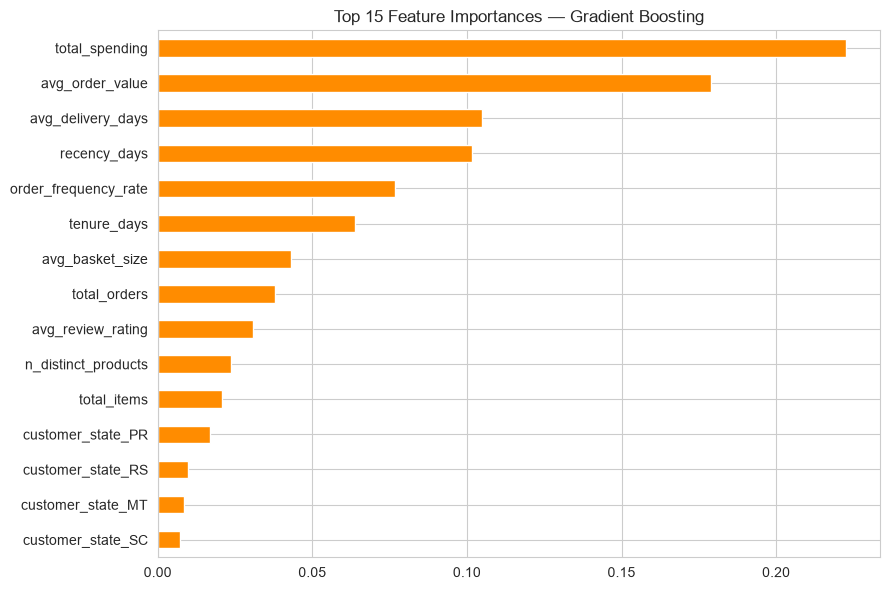

total_spending          0.222470
avg_order_value         0.178996
avg_delivery_days       0.105018
recency_days            0.101725
order_frequency_rate    0.076607
tenure_days             0.063957
avg_basket_size         0.043194
total_orders            0.038036
avg_review_rating       0.030926
n_distinct_products     0.023791
total_items             0.020948
customer_state_PR       0.017049
customer_state_RS       0.009892
customer_state_MT       0.008568
customer_state_SC       0.007168
dtype: float64


In [8]:
feature_names = (feature_cols +
                  list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)))
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.sort_values().plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(f"Top 15 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.savefig(OUT + "clv_feature_importance.png", dpi=110)
    plt.show()
    print(imp)

## 7. Save best model + artifacts

In [9]:
full_pipeline = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
joblib.dump(full_pipeline, OUT + "clv_prediction_pipeline.joblib")
joblib.dump(feature_cols, OUT + "clv_prediction_feature_cols.joblib")
results_df.to_csv(OUT + "clv_model_comparison.csv", index=False)
feat.to_csv(OUT + "clv_prediction_dataset.csv", index=False)
print("Saved: clv_prediction_pipeline.joblib, clv_model_comparison.csv, clv_prediction_dataset.csv")

Saved: clv_prediction_pipeline.joblib, clv_model_comparison.csv, clv_prediction_dataset.csv


## Key takeaways (honest reporting)
- Like Phase 6, the target here is heavily zero-inflated (~99% of customers spend R$0 in the
  90-day forward window) — the same underlying "mostly one-time buyers" pattern seen throughout
  this project. R² on the raw scale will look low/near-zero for this reason: predicting a mostly-
  zero target is fundamentally different from predicting continuous, always-positive revenue.
- MAPE is reported with an epsilon floor since true MAPE is undefined when actual spend is R$0
  for ~99% of rows — the standard metric formula breaks down on this kind of target and this is
  disclosed rather than silently worked around.
- The practical business reading: for THIS dataset and 90-day window, a full CLV model would
  need either a longer horizon, a two-stage model (classify "will spend again" first, then
  regress the amount conditional on spending), or additional signals (marketing touches, browse
  behavior) not present in this transactional-only dataset.
- Total historical spending and order frequency are the strongest predictors of any future spend
  that does occur — consistent with RFM theory (past behavior predicts future behavior).